# Análisis de Correlación de Indicadores Comerciales – City Club

## 1. Contexto y objetivo

### Contexto

La base de datos utilizada para este análisis corresponde a una base maestra de ventas de membresías de City Club a nivel nacional. La información se encuentra organizada en hojas independientes para los años 2024, 2025 y 2026.

Cada registro contiene información relacionada con la operación comercial de las sucursales, incluyendo la fecha, sucursal, club, renovaciones, afiliaciones, membresías adicionales, beneficios Premia, duplicados, punto de venta, ingresos por Premia e ingresos totales.

### Objetivo

El objetivo de este análisis es explorar las relaciones entre los principales indicadores comerciales de City Club para identificar patrones de asociación entre las diferentes métricas del negocio.

Este análisis tiene un enfoque exploratorio y correlacional. Su propósito es generar hipótesis que puedan apoyar la toma de decisiones comerciales y operativas, sin asumir relaciones de causalidad entre las variables analizadas.

## 2. Preparación y supuestos

- **Dataset:** Base de Datos Maestra de City Club (2024–2026).

- **Periodo analizado:** Enero de 2024 a la fecha disponible de 2026.

- **Variables analizadas:**
  - Afiliaciones
  - Renovaciones
  - Segundas adicionales
  - Cantidad de beneficios Premia
  - Ganancia por Premia
  - Duplicados
  - Ingresos Totales

- **Variables excluidas del análisis de correlación:**
  - Fecha
  - Sucursal
  - Club
  - Punto de venta

Estas variables fueron excluidas por ser identificadores o variables categóricas, por lo que requieren técnicas de análisis diferentes a la correlación de Pearson o Spearman.

- **Supuesto clave:** El análisis tiene un enfoque correlacional y exploratorio. Los coeficientes obtenidos describen asociaciones entre variables, pero no permiten establecer relaciones de causa y efecto.

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from scipy.stats import pointbiserialr, chi2_contingency

## 3. Carga e inspección de los datos

En esta etapa se carga la base de datos maestra y se realiza una inspección inicial para verificar la estructura del conjunto de datos, identificar los tipos de variables, revisar posibles valores faltantes y obtener un resumen estadístico de las variables numéricas.

Esta revisión permite asegurar que la información sea consistente antes de aplicar técnicas de análisis exploratorio y correlacional.


In [2]:
df_ventas_2024 = pd.read_excel(r'C:\Users\santo\Desktop\CityClubMembresias\CityClub Ventas Membresias 2024.xlsx')
df_ventas_2025 = pd.read_excel(r'C:\Users\santo\Desktop\CityClubMembresias\CityClub Ventas Membresias 2025.xlsx')
df_ventas_2026 = pd.read_excel(r'C:\Users\santo\Desktop\CityClubMembresias\CityClub Ventas Membresias 2026.xlsx')

Agregar una columna de año

In [3]:
df_ventas_2024['año'] = 2024
df_ventas_2025['año'] = 2025
df_ventas_2026['año'] = 2026

Unir

In [4]:
df = pd.concat([df_ventas_2024,df_ventas_2025,df_ventas_2026],ignore_index = True)

### Integración de fuentes de datos

La información se encontraba distribuida en tres hojas independientes correspondientes a los años 2024, 2025 y 2026. Debido a que las tres hojas comparten la misma estructura y contienen los mismos indicadores comerciales, se integraron en un único conjunto de datos para facilitar el análisis longitudinal y aumentar el número de observaciones disponibles.

Adicionalmente, se incorporó una variable de año para conservar la trazabilidad temporal de cada registro.


In [5]:
df.shape

(32620, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32620 entries, 0 to 32619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             32620 non-null  datetime64[ns]
 1   sucursal          32620 non-null  int64         
 2   club              32620 non-null  object        
 3   renovaciones      32325 non-null  float64       
 4   afiliaciones      32324 non-null  float64       
 5   ad2               32323 non-null  float64       
 6   premias_cant      32620 non-null  float64       
 7   duplicados        32320 non-null  float64       
 8   punto_de_venta    32329 non-null  float64       
 9   premias_$         32288 non-null  float64       
 10  ingresos_totales  32620 non-null  float64       
 11  año               32620 non-null  int64         
dtypes: datetime64[ns](1), float64(8), int64(2), object(1)
memory usage: 3.0+ MB


In [7]:
df.columns.tolist()

['fecha',
 'sucursal',
 'club',
 'renovaciones',
 'afiliaciones',
 'ad2',
 'premias_cant',
 'duplicados',
 'punto_de_venta',
 'premias_$',
 'ingresos_totales',
 'año']

## Revision de valores nulos
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

In [8]:
df.isnull().sum()

fecha                 0
sucursal              0
club                  0
renovaciones        295
afiliaciones        296
ad2                 297
premias_cant          0
duplicados          300
punto_de_venta      291
premias_$           332
ingresos_totales      0
año                   0
dtype: int64

Mostrar ejemplos reales de filas con nulos.

In [9]:
df[df.isnull().any(axis=1)].head(20)

,fecha,sucursal,club,renovaciones,afiliaciones,ad2,premias_cant,duplicados,punto_de_venta,premias_$,ingresos_totales,año
14154,2024-10-04,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14155,2024-10-05,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14156,2024-10-06,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14157,2024-10-07,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14158,2024-10-08,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14159,2024-10-09,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14160,2024-10-10,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14161,2024-10-11,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14162,2024-10-12,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024
14163,2024-10-13,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2024


In [10]:
df[(df['club']=='Cordilleras') & (df['año']==2025)].head(10)

,fecha,sucursal,club,renovaciones,afiliaciones,ad2,premias_cant,duplicados,punto_de_venta,premias_$,ingresos_totales,año
28388,2025-01-01,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28389,2025-01-02,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28390,2025-01-03,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28391,2025-01-04,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28392,2025-01-05,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28393,2025-01-06,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28394,2025-01-07,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28395,2025-01-08,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28396,2025-01-09,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025
28397,2025-01-10,1041,Cordilleras,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,2025


### Observaciones sobre valores faltantes

Durante la revisión de los registros con valores faltantes se identificó que parte de ellos corresponden a la sucursal Cordilleras, la cual dejó de operar a partir de octubre de 2024.

En estos casos se observan ingresos totales iguales a cero y ausencia de actividad comercial, por lo que los valores faltantes no representan errores de captura sino una condición operativa real del negocio.

Este hallazgo se consideró durante la interpretación de los resultados para evitar conclusiones incorrectas derivadas de la falta de actividad de la sucursal.


In [11]:
df[df['renovaciones'].isnull()]['club'].value_counts()

Cordilleras          254
Huayacan              20
Villahermosa           2
Monclova               2
Hermosillo             1
Cuidad del Carmen      1
Cuidad Victoria        1
Piedras Negras         1
Ecatepec               1
San Jose               1
Culiacan               1
Ixtapaluca             1
Gomez Palacio          1
Coacalco               1
Reynosa                1
Nuevo Laredo           1
Tampico                1
Los Cabos              1
Saltillo               1
Chihuahua              1
Queretaro              1
Name: club, dtype: int64

In [12]:
df_corr = df.dropna(
    subset=[
        'renovaciones',
        'afiliaciones',
        'ad2',
        'duplicados',
        'premias_$'
    ]
)

In [13]:
df_corr.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32276 entries, 0 to 32588
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             32276 non-null  datetime64[ns]
 1   sucursal          32276 non-null  int64         
 2   club              32276 non-null  object        
 3   renovaciones      32276 non-null  float64       
 4   afiliaciones      32276 non-null  float64       
 5   ad2               32276 non-null  float64       
 6   premias_cant      32276 non-null  float64       
 7   duplicados        32276 non-null  float64       
 8   punto_de_venta    32276 non-null  float64       
 9   premias_$         32276 non-null  float64       
 10  ingresos_totales  32276 non-null  float64       
 11  año               32276 non-null  int64         
dtypes: datetime64[ns](1), float64(8), int64(2), object(1)
memory usage: 3.2+ MB


### Tratamiento de valores faltantes

La revisión de los valores faltantes mostró que la mayoría de los registros incompletos correspondían a la sucursal Cordilleras, la cual dejó de operar durante el periodo analizado. También se identificaron algunos registros aislados asociados a retrasos o ausencias en el reporte de información por parte de determinadas sucursales.

Dado que los valores faltantes representaban menos del 1% del total de observaciones y que el objetivo del análisis es exploratorio, se optó por excluir dichos registros para garantizar la consistencia de los cálculos de correlación.


In [14]:
df_corr.describe()

,sucursal,renovaciones,afiliaciones,ad2,premias_cant,duplicados,punto_de_venta,premias_$,ingresos_totales,año
count,32276.000000,32276.000000,32276.000000,32276.000000,32276.000000,32276.000000,32276.000000,32276.000000,32276.000000,32276.000000
mean,1020.537024,30.362684,10.767164,7.164147,4.938411,4.009914,9680.596497,1073.294735,10753.891232,2024.656556
std,11.874778,17.797601,7.956460,7.010980,4.206366,4.041615,5211.537530,906.759038,5588.336120,0.657812
min,1001.000000,0.000000,0.000000,0.000000,-1.023810,0.000000,0.000000,-215.000000,0.000000,2024.000000
25%,1010.000000,19.000000,6.000000,3.000000,2.052381,1.000000,6185.000000,431.030000,6961.000000,2024.000000
50%,1020.000000,27.000000,9.000000,6.000000,4.104762,3.000000,8663.850172,862.000000,9698.000000,2025.000000
75%,1030.000000,38.000000,13.000000,9.000000,6.613757,6.000000,11897.000000,1508.577500,13275.850000,2025.000000
max,1044.000000,631.000000,386.000000,129.000000,94.725238,90.000000,113336.000000,19892.300000,125865.720000,2026.000000


In [15]:
df_corr[df_corr['premias_cant']<0]

,fecha,sucursal,club,renovaciones,afiliaciones,ad2,premias_cant,duplicados,punto_de_venta,premias_$,ingresos_totales,año
27706,2025-02-18,1039,Cuidad Victoria,18.0,4.0,10.0,-1.02381,3.0,5237.0,-215.0,5022.0,2025


In [16]:
(df_corr['premias_cant']<0).sum()

1

In [17]:
df_corr.loc[
    df_corr['premias_cant'] < 0,
    'premias_cant'
] = 1.02381

df_corr.loc[
    df_corr['premias_$'] < 0,
    'premias_$'
] = 215

In [18]:
(df_corr['premias_cant'] < 0).sum()

0

In [19]:
(df_corr['premias_$'] < 0).sum()

0

### Corrección de inconsistencias

Durante la revisión de calidad de los datos se identificó un único registro con valores negativos en las variables relacionadas con beneficios Premia. Debido a que estas métricas representan cantidades e ingresos, valores negativos no son válidos desde la perspectiva operativa del negocio.

Tras verificar el registro, se determinó que correspondía a un error de captura, por lo que los valores fueron corregidos antes de realizar el análisis de correlación.


## 5. Visualización de relaciones

Con el conjunto de datos preparado, se exploran las relaciones entre los principales indicadores comerciales mediante una matriz de correlación.

Esta visualización permite identificar asociaciones positivas y negativas entre las variables analizadas, así como detectar patrones que posteriormente serán examinados con mayor detalle mediante coeficientes de correlación y gráficos de dispersión.

Las correlaciones observadas representan asociaciones estadísticas y no deben interpretarse como relaciones de causalidad.


In [20]:
variables_corr = [
    'renovaciones',
    'afiliaciones',
    'ad2',
    'premias_cant',
    'duplicados',
    'premias_$',
    'ingresos_totales'
]

corr_df = df_corr[variables_corr]

### Matriz de correlación

In [21]:
corr_matrix = corr_df.corr(method='pearson')
corr_matrix

,renovaciones,afiliaciones,ad2,premias_cant,duplicados,premias_$,ingresos_totales
renovaciones,1.000000,0.292354,0.513221,0.253768,0.316880,0.270007,0.883984
afiliaciones,0.292354,1.000000,0.328977,0.368742,0.310656,0.364546,0.597144
ad2,0.513221,0.328977,1.000000,0.179132,0.218662,0.178069,0.553166
premias_cant,0.253768,0.368742,0.179132,1.000000,0.212579,0.993497,0.458267
duplicados,0.316880,0.310656,0.218662,0.212579,1.000000,0.214263,0.387109
premias_$,0.270007,0.364546,0.178069,0.993497,0.214263,1.000000,0.482658
ingresos_totales,0.883984,0.597144,0.553166,0.458267,0.387109,0.482658,1.000000


### Heatmap

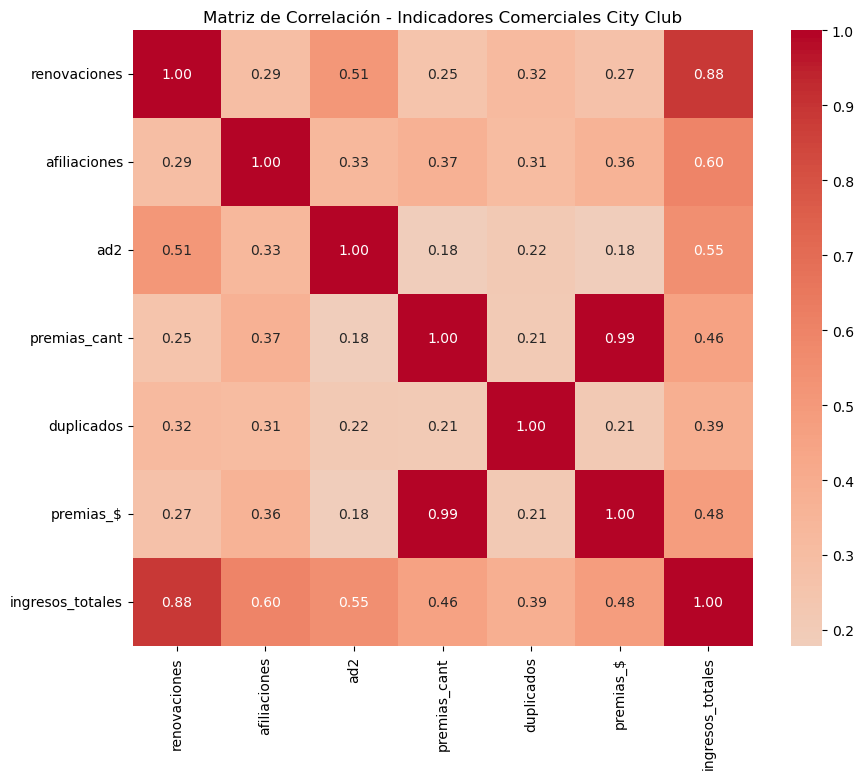

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Matriz de Correlación - Indicadores Comerciales City Club')
plt.show()

### Hallazgo 1 — Renovaciones e ingresos totales

**Evidencia numérica:** Correlación de Pearson = 0.884

**Interpretación**

Las renovaciones presentan la asociación positiva más fuerte con los ingresos totales entre todas las variables analizadas. Las sucursales con mayores niveles de renovación tienden a registrar mayores ingresos.

**No podemos afirmar**

Que incrementar las renovaciones provoque directamente un aumento en los ingresos, ya que el análisis es correlacional y no controla otros factores que podrían influir en ambas variables.

**Implicación de negocio**

Los resultados sugieren que la retención de socios podría ser un indicador clave del desempeño comercial y merece un análisis más profundo en futuras investigaciones.


### Renovaciones vs Ingresos

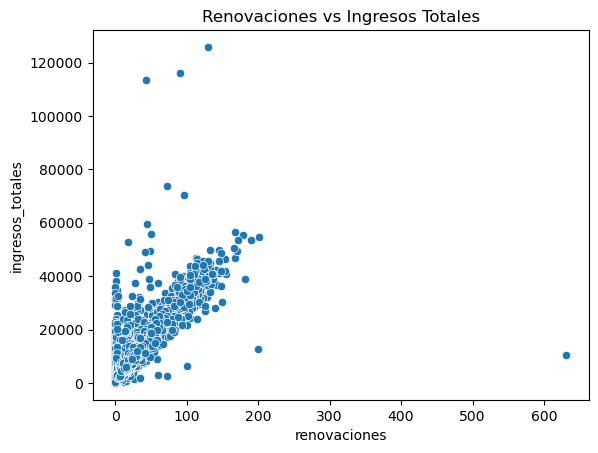

In [23]:
sns.scatterplot(data=df_corr, x='renovaciones', y='ingresos_totales')

plt.title('Renovaciones vs Ingresos Totales')
plt.show()

### Afiliaciones vs Ingresos

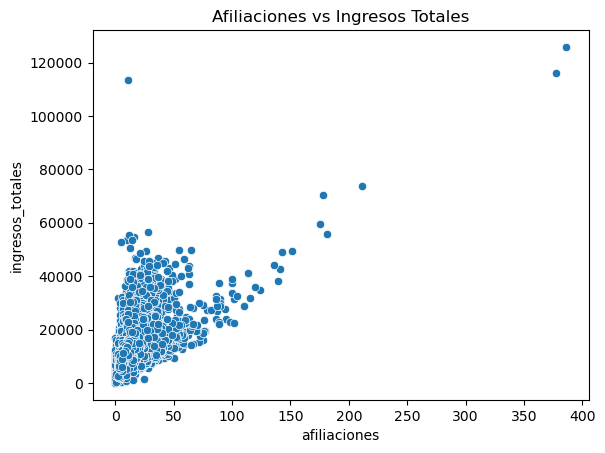

In [24]:
sns.scatterplot(data=df_corr, x='afiliaciones', y='ingresos_totales')

plt.title('Afiliaciones vs Ingresos Totales')
plt.show()

### AD2 vs Ingresos

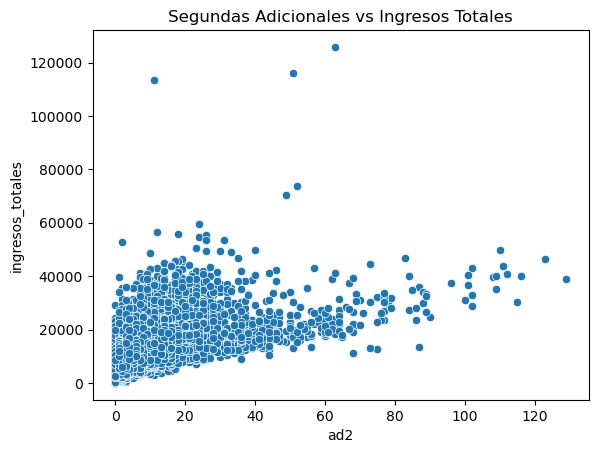

In [25]:
sns.scatterplot(data=df_corr,x= 'ad2', y= 'ingresos_totales')

plt.title('Segundas Adicionales vs Ingresos Totales')
plt.show()

Las renovaciones muestran la asociación más fuerte con los ingresos totales (r=0.884), superando significativamente a las afiliaciones y otros productos complementarios. Esto sugiere que las sucursales con mejor desempeño en retención de socios tienden también a generar mayores ingresos comerciales.

## Hallazgos finales del análisis nacional
### Hallazgo 1 — Renovaciones e ingresos totales

#### Evidencia visual: Scatterplot Renovaciones vs Ingresos Totales.

Evidencia numérica: Pearson = 0.884.

#### Interpretación

Las renovaciones presentan la asociación positiva más fuerte con los ingresos totales entre todas las variables analizadas. Los clubes con mayores niveles de renovación tienden a generar mayores ingresos.

#### No podemos afirmar

Que incrementar las renovaciones provoque directamente un aumento en los ingresos, ya que el análisis es correlacional.

#### Implicación de negocio

La retención de socios parece ser uno de los indicadores comerciales más relevantes y merece seguimiento prioritario por parte de la operación.

### Hallazgo 2 — Afiliaciones e ingresos totales

Evidencia numérica: Pearson = 0.597.

#### Interpretación

Las afiliaciones muestran una asociación positiva moderada con los ingresos. Los clubes que captan más socios nuevos suelen registrar mayores ingresos, aunque la relación es considerablemente menor que la observada para renovaciones.

#### Implicación de negocio

La adquisición de nuevos socios sigue siendo importante, pero los resultados sugieren que la permanencia de los socios podría tener un mayor peso en el desempeño comercial.

### Hallazgo 3 — AD2 e ingresos totales

Evidencia numérica: Pearson = 0.553.

#### Interpretación

La venta de segundas adicionales mantiene una relación positiva moderada con los ingresos totales.

#### Implicación de negocio

Los productos complementarios pueden contribuir al crecimiento comercial, aunque su asociación es menor que la de las renovaciones.

## Limitaciones

- El análisis es correlacional y no permite establecer causalidad.
- Los resultados agregan información de todos los clubes a nivel nacional.
- Las diferencias en tamaño y volumen de venta entre sucursales podrían influir en las correlaciones observadas.
- Factores no incluidos en el análisis, como campañas comerciales, ubicación, tamaño del club o características demográficas, podrían afectar los resultados.

# Análisis por sucursal

In [26]:
clubes = df_corr.groupby('club').agg({
    'renovaciones':'sum',
    'afiliaciones':'sum',
    'ad2':'sum',
    'premias_cant':'sum',
    'ingresos_totales':'sum'
})

clubes.head()

,renovaciones,afiliaciones,ad2,premias_cant,ingresos_totales
club,,,,,
Cancun,33435.0,12493.0,8997.0,6406.668727,1.223402e+07
Chihuahua,23319.0,8564.0,3592.0,1212.588476,7.695387e+06
Coacalco,14692.0,7097.0,4380.0,4724.041819,6.157617e+06
Colima,27788.0,5823.0,8470.0,3456.780880,8.624470e+06
Cordilleras,7777.0,13980.0,1779.0,5051.406624,6.289049e+06


In [27]:
clubes.shape

(44, 5)

In [28]:
corr_clubes = clubes.corr()

corr_clubes['ingresos_totales'].sort_values(ascending=False)

ingresos_totales    1.000000
renovaciones        0.968158
ad2                 0.844588
afiliaciones        0.712261
premias_cant        0.490673
Name: ingresos_totales, dtype: float64

### Diferencias estructurales entre clubes

Al agregar la información por sucursal y analizar los indicadores acumulados, las asociaciones con los ingresos totales aumentan significativamente.

Las renovaciones presentan la correlación más alta con los ingresos totales (r = 0.968), seguidas por las segundas adicionales (r = 0.845) y las afiliaciones (r = 0.712).

Esto sugiere que las diferencias de desempeño entre clubes tienen una influencia importante en los resultados observados a nivel nacional.

Los clubes con mayores volúmenes de renovaciones y productos complementarios tienden a concentrar una proporción significativa de los ingresos de la compañía.

### Nuevo Laredo

In [29]:
nuevo_laredo = df_corr[df_corr['club'] == 'Nuevo Laredo']

In [30]:
nuevo_laredo.shape

(820, 12)

In [31]:
corr_nl = nuevo_laredo[
    ['renovaciones',
     'afiliaciones',
     'ad2',
     'premias_cant',
     'ingresos_totales']
].corr()

corr_nl['ingresos_totales'].sort_values(ascending=False)

ingresos_totales    1.000000
renovaciones        0.868818
afiliaciones        0.627135
ad2                 0.503500
premias_cant        0.501607
Name: ingresos_totales, dtype: float64

En Nuevo Laredo las renovaciones siguen siendo el indicador más asociado a los ingresos totales, replicando el patrón observado a nivel nacional.

### Monclova

In [32]:
monclova = df_corr[df_corr['club'] == 'Monclova']

monclova.shape

(818, 12)

In [33]:
corr_mon = monclova[
    ['renovaciones',
     'afiliaciones',
     'ad2',
     'premias_cant',
     'ingresos_totales']
].corr()

corr_mon['ingresos_totales'].sort_values(ascending=False)

ingresos_totales    1.000000
renovaciones        0.950245
ad2                 0.573769
afiliaciones        0.526498
premias_cant        0.153276
Name: ingresos_totales, dtype: float64

### Santa Monica

In [34]:
santa_monica = df_corr[df_corr['club'] == 'Santa Monica']

santa_monica.shape

(821, 12)

In [35]:
corr_sm = santa_monica[
    ['renovaciones',
     'afiliaciones',
     'ad2',
     'premias_cant',
     'ingresos_totales']
].corr()

corr_sm['ingresos_totales'].sort_values(ascending=False)

ingresos_totales    1.000000
renovaciones        0.876443
afiliaciones        0.771576
premias_cant        0.616018
ad2                 0.464871
Name: ingresos_totales, dtype: float64

El análisis por sucursal mostró diferencias relevantes en la importancia de los productos complementarios. Mientras que en Santa Mónica las afiliaciones presentan una asociación elevada con los ingresos (r = 0.772), en Monclova destacan las segundas adicionales (r = 0.574) y Premias muestra una relación débil (r = 0.153). Sin embargo, las renovaciones se mantienen como el indicador más asociado a los ingresos en los tres clubes analizados, con correlaciones entre 0.868 y 0.950, lo que confirma la consistencia del hallazgo observado a nivel nacional.